In [66]:
import pandas as pd

In [67]:
columns_headers = [
    "time", "gender", "highschool_%", "study_year","faculty","ung_grade_2023","accomodation","allowance","scholarship","study_hours",
    "party_week","drinks_night","missed_classes", "failed_classes", "in_relationship","parent_approve","relation_parent"
]
student_df = pd.read_csv("F:\github\Data preprocessing\Student_survay.csv", names=columns_headers, header=0)

<>:5: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:5: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
C:\Users\User\AppData\Local\Temp\ipykernel_16516\4292004400.py:5: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  student_df = pd.read_csv("F:\github\Data preprocessing\Student_survay.csv", names=columns_headers, header=0)


In [68]:
student_df.drop("time",axis=1,inplace=True
                )

EDA

In [69]:
student_df.isna().sum()

gender              2
highschool_%        7
study_year         73
faculty             7
ung_grade_2023     86
accomodation       23
allowance          31
scholarship         8
study_hours         3
party_week          2
drinks_night        2
missed_classes      3
failed_classes      3
in_relationship     3
parent_approve      4
relation_parent     3
dtype: int64

In [70]:
student_df.describe

<bound method NDFrame.describe of      gender  highschool_% study_year                         faculty  \
0    Female          76.0   2nd Year          Arts & Social Sciences   
1      Male          89.0   2nd Year  Economic & Management Sciences   
2      Male          76.0   1st Year                    AgriSciences   
3      Male          89.0   2nd Year                     Engineering   
4    Female          74.0   2nd Year          Arts & Social Sciences   
..      ...           ...        ...                             ...   
401  Female          74.0        NaN                         Science   
402  Female          73.0   2nd Year  Economic & Management Sciences   
403  Female          86.0   1st Year                             NaN   
404    Male          85.0        NaN  Economic & Management Sciences   
405  Female          80.0   1st Year                             NaN   

     ung_grade_2023                                     accomodation  \
0              72.0  Private 

In [71]:
student_df.shape

(406, 16)

In [72]:
#Gender Distribution in the dataset
student_df.gender.value_counts(normalize=True)

gender
Male      0.534653
Female    0.465347
Name: proportion, dtype: float64

in the given study, 53.5% student are male and 46.5% are female

In [73]:
student_df.head()

,gender,highschool_%,study_year,faculty,ung_grade_2023,accomodation,allowance,scholarship,study_hours,party_week,drinks_night,missed_classes,failed_classes,in_relationship,parent_approve,relation_parent
0,Female,76.0,2nd Year,Arts & Social Sciences,72.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,8+,Only weekends,8+,3,0,Yes,Yes,Very close
1,Male,89.0,2nd Year,Economic & Management Sciences,75.0,Private accommodation/ stay with family/friends,R 7001 - R 8000,"Yes (NSFAS, etc...)",8+,Only weekends,3-5,4+,0,No,Yes,Very close
2,Male,76.0,1st Year,AgriSciences,55.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,2,8+,3,0,No,Yes,Very close
3,Male,89.0,2nd Year,Engineering,84.0,Private accommodation/ stay with family/friends,R 6001 - R 7000,No,3-5,3,8+,2,0,Yes,Yes,Very close
4,Female,74.0,2nd Year,Arts & Social Sciences,52.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,Only weekends,5-8,1,3,No,Yes,Fair


In [74]:
student_df.head(1)

,gender,highschool_%,study_year,faculty,ung_grade_2023,accomodation,allowance,scholarship,study_hours,party_week,drinks_night,missed_classes,failed_classes,in_relationship,parent_approve,relation_parent
0,Female,76.0,2nd Year,Arts & Social Sciences,72.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,8+,Only weekends,8+,3,0,Yes,Yes,Very close


In [75]:
#Relation betn Parent Approval and Parent Relationship
table=pd.crosstab(student_df.parent_approve,student_df.relation_parent)
table[["Close","Distant","Fair", "Very close"]]
table.T

parent_approve,No,Yes
relation_parent,,
Close,18,79
Distant,1,1
Fair,9,25
Very close,20,248


In [76]:
table.T

parent_approve,No,Yes
relation_parent,,
Close,18,79
Distant,1,1
Fair,9,25
Very close,20,248


<Axes: title={'center': 'Relation Between Parent Approval and Parent Relationship'}, xlabel='Degree of Parent Relationship', ylabel='Student Count'>

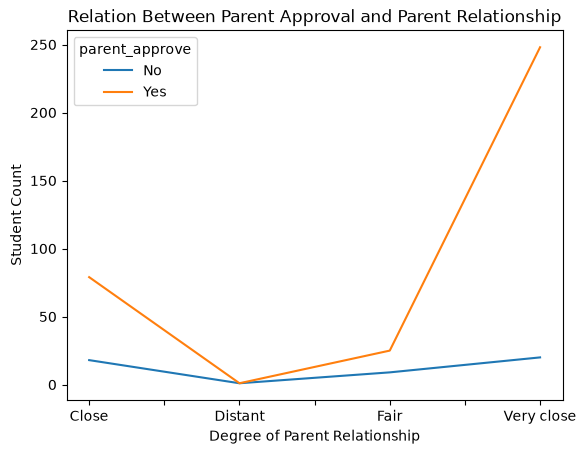

In [77]:
table.T.plot(kind="line"
             ,title="Relation Between Parent Approval and Parent Relationship",
             ylabel="Student Count",
             xlabel="Degree of Parent Relationship")

In [78]:
#Relation between Parent Relationship and Grade in Highschool
group_parent_relation=student_df.groupby(by="relation_parent")

In [79]:
group_parent_relation.head(2)

,gender,highschool_%,study_year,faculty,ung_grade_2023,accomodation,allowance,scholarship,study_hours,party_week,drinks_night,missed_classes,failed_classes,in_relationship,parent_approve,relation_parent
0,Female,76.0,2nd Year,Arts & Social Sciences,72.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,8+,Only weekends,8+,3,0,Yes,Yes,Very close
1,Male,89.0,2nd Year,Economic & Management Sciences,75.0,Private accommodation/ stay with family/friends,R 7001 - R 8000,"Yes (NSFAS, etc...)",8+,Only weekends,3-5,4+,0,No,Yes,Very close
4,Female,74.0,2nd Year,Arts & Social Sciences,52.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,Only weekends,5-8,1,3,No,Yes,Fair
9,Male,83.0,NaN,Science,NaN,NaN,R 6001 - R 7000,No,3-5,3,5-8,4+,0,No,Yes,Close
10,Female,75.0,NaN,AgriSciences,NaN,NaN,R 4001- R 5000,No,5-8,2,5-8,0,0,No,Yes,Close
16,Female,86.0,NaN,Engineering,NaN,Private accommodation/ stay with family/friends,NaN,No,3-5,1,3-5,0,0,No,Yes,Fair
54,Male,98.0,1st Year,Engineering,89.0,Private accommodation/ stay with family/friends,R 4001- R 5000,"Yes (NSFAS, etc...)",1-3,Only weekends,8+,0,4+,Yes,No,Distant
116,Male,85.0,1st Year,Science,88.0,Private accommodation/ stay with family/friends,R 4001- R 5000,"Yes (NSFAS, etc...)",8+,Only weekends,0,0,0,Yes,Yes,Distant


In [80]:
relation=group_parent_relation['highschool_%'].aggregate(['min','max','mean'])

In [81]:
relation=relation.T[["Distant","Fair","Close","Very close"]]

In [82]:
relation

relation_parent,Distant,Fair,Close,Very close
min,85.0,55.000000,60.00,34.000000
max,98.0,95.500000,98.33,99.000000
mean,91.5,78.357143,77.69,77.960114


<Axes: xlabel='relation_parent'>

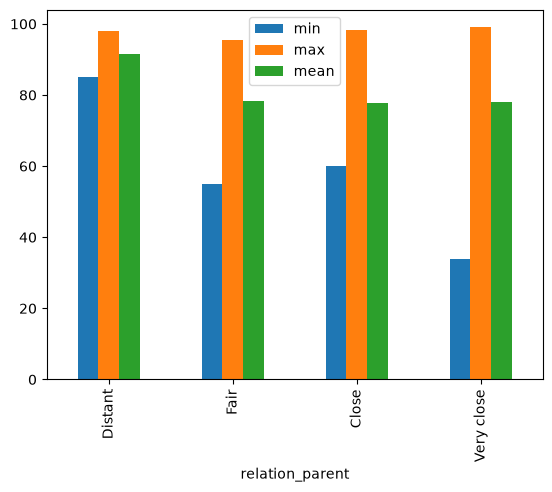

In [83]:
relation.T.plot(kind="bar")

As per given chart, we can see min values have inverse relationship with "Parent Relation",whereas ,mean score for "Distant" relatiionship seems high thean other categories.

<Axes: xlabel='highschool_%', ylabel='ung_grade_2023'>

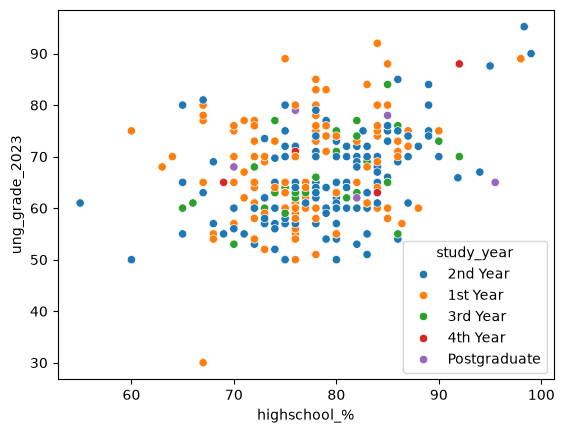

In [84]:
#Relationship Bentween highschool grade and Uni grade
import seaborn as sns
sns.scatterplot(student_df,x='highschool_%',y='ung_grade_2023',hue='study_year')

In [85]:
student_df.ung_grade_2023.corr(student_df['highschool_%'])

np.float64(0.29910363012959085)

Weak Positive Correlation



In [86]:
#scholarship
student_df.scholarship.value_counts()

scholarship
No                     352
Yes (NSFAS, etc...)     46
Name: count, dtype: int64

In [87]:
student_df.head(1)

,gender,highschool_%,study_year,faculty,ung_grade_2023,accomodation,allowance,scholarship,study_hours,party_week,drinks_night,missed_classes,failed_classes,in_relationship,parent_approve,relation_parent
0,Female,76.0,2nd Year,Arts & Social Sciences,72.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,8+,Only weekends,8+,3,0,Yes,Yes,Very close


In [88]:
student_df.allowance.value_counts()

allowance
R 4001- R 5000     159
R 5001 - R 6000    101
R 6001 - R 7000     58
R 7001 - R 8000     30
R 8000+             27
Name: count, dtype: int64

In [89]:
student_df.party_week.value_counts(
    
)

party_week
Only weekends    113
1                108
2                 87
3                 63
0                 17
4+                16
Name: count, dtype: int64

In [90]:
table = pd.crosstab(student_df['party_week'], student_df['allowance'])

table = table.reindex(
    [0, 1, 2, 3, '4+', 'Only weekends'],
    fill_value=0
)


In [91]:
student_df[
    (student_df['party_week'] == 'Only weekends') &
    (student_df['allowance'] == "R 4001- R 5000")
].value_counts()


gender  highschool_%  study_year  faculty                         ung_grade_2023  accomodation                                     allowance       scholarship          study_hours  party_week     drinks_night  missed_classes  failed_classes  in_relationship  parent_approve  relation_parent
Female  76.0          2nd Year    Arts & Social Sciences          72.0            Private accommodation/ stay with family/friends  R 4001- R 5000  No                   8+           Only weekends  8+            3               0               Yes              Yes             Very close         1
        74.0          2nd Year    Arts & Social Sciences          52.0            Private accommodation/ stay with family/friends  R 4001- R 5000  No                   3-5          Only weekends  5-8           1               3               No               Yes             Fair               1
        87.0          1st Year    Science                         75.0            Private accommodation/ stay with fa

In [92]:
table

allowance,R 4001- R 5000,R 5001 - R 6000,R 6001 - R 7000,R 7001 - R 8000,R 8000+
party_week,,,,,
0,0,0,0,0,0
1,0,0,0,0,0
2,0,0,0,0,0
3,0,0,0,0,0
4+,6,4,1,2,3
Only weekends,50,29,8,6,9


EDA ->DATA CLEANING

In [93]:
#check for duplicates
student_df[student_df.duplicated()]

,gender,highschool_%,study_year,faculty,ung_grade_2023,accomodation,allowance,scholarship,study_hours,party_week,drinks_night,missed_classes,failed_classes,in_relationship,parent_approve,relation_parent
144,Female,85.0,2nd Year,Economic & Management Sciences,73.0,Private accommodation/ stay with family/friends,R 5001 - R 6000,No,8+,2,1-3,4+,0,Yes,Yes,Very close
232,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
325,Male,71.0,NaN,Economic & Management Sciences,NaN,Private accommodation/ stay with family/friends,R 4001- R 5000,"Yes (NSFAS, etc...)",3-5,2,8+,1,0,Yes,Yes,Very close


In [94]:
#entire row is null
student_df[student_df.isna().sum(axis=1)==len(student_df.columns)
           ]

,gender,highschool_%,study_year,faculty,ung_grade_2023,accomodation,allowance,scholarship,study_hours,party_week,drinks_night,missed_classes,failed_classes,in_relationship,parent_approve,relation_parent
224,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
232,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


##Manipulation /Cleaning /Transforming /Processing

Unwanted columns removal
Duplicated value removal
Null vale Handling
Outlier handling
Feature Engineering
Encoding
Normalization(post -Processing)

In [95]:
student_df.shape

(406, 16)

In [96]:
#remove duplicated rows
student_df.drop_duplicates(inplace=True)


In [97]:
student_df.shape

(403, 16)

3 Duplicate values/rows removed

In [98]:
#counting null values
student_df.isna().sum()

gender              1
highschool_%        6
study_year         71
faculty             6
ung_grade_2023     84
accomodation       22
allowance          30
scholarship         7
study_hours         2
party_week          1
drinks_night        1
missed_classes      2
failed_classes      2
in_relationship     2
parent_approve      3
relation_parent     2
dtype: int64

In [99]:
#Removing Rows with 60% /9 null values
student_df.dropna(axis=0,thresh=6,inplace=True)

In [100]:
student_df.isna().sum()

gender              0
highschool_%        5
study_year         70
faculty             5
ung_grade_2023     83
accomodation       21
allowance          29
scholarship         6
study_hours         1
party_week          0
drinks_night        0
missed_classes      1
failed_classes      1
in_relationship     1
parent_approve      2
relation_parent     1
dtype: int64

In [ ]:
##Domain Experts Say---do first
###Remove Null  Values or Imputation (mode)
##Null as Feature
